# Hands-on Introduction to Deep Learning for Early Warnings of Tipping Points

## Practical Session
As we have learned the basics of DL and how it is used to anticipate tipping points, it is your turn to improve your understanding the CNN-LSTM architecture and how choices such as detrending and kernel size can affect the predictions and uncertainty of predictions from trained DL models. Most of the models are already pretrained using a similar procedure to those seem in the lecture. I am hoping, we may be able to use the limited resources on [Google Colab](https://colab.research.google.com/) free version to train the model in the last example. The code for the first exercise has already been written and it may be adopted for the subsequent exercises.

It should be noted that the goal of these exercises is not to teach you PyTorch but to understand how the choice of hyperparameters of a DL model and the preprocessing of the training data can determine whether your deep learning model has good early warning skills or not. 


This notebook can be open in Google Colab via this [link](https://colab.research.google.com/github/muhammedfadera/DL4EWS-Dartington/blob/master/practical_session.ipynb). Run the following code to get set up. 


In [ ]:
import os
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists("/content/DL4EWS-Dartington"):
        !git clone https://github.com/muhammedfadera/DL4EWS-Dartington.git 
    !pip install statsmodels scipy

    %cd DL4EWS-Dartington

In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import random
from utilities import *


device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)


def set_reprodcible_seed(seed=16022026):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class CNN_LSTM_TippingClassifier(torch.nn.Module):
    def __init__(self, hidden_size, input_size = 1, output_size = 2, 
                 n_features = 10, seq_length = 1500,
                 kernel_size = 12, seed=16022026):

       super(CNN_LSTM_TippingClassifier, self).__init__() 
       torch.manual_seed(seed)
       np.random.seed(seed)

       self.conv = nn.Sequential(
        #  convolution
        nn.Conv1d(
            in_channels=input_size, out_channels=n_features,
            kernel_size=kernel_size, padding=0, stride=1
        ),
        # dropout with 0.1 probability
        nn.Dropout(0.1),
        # max pool
        nn.MaxPool1d(kernel_size=kernel_size, stride = 1, padding=0)
       )
       moving_window = 2*(kernel_size - 1) 
       n_out = seq_length - moving_window
       self.n_out = n_out
       self.n_features = n_features
       self.input_size = input_size
       self.RNN = nn.LSTM(input_size=n_features, hidden_size=hidden_size, bias=True, 
                          num_layers=2, batch_first=True)
       self.Wout = nn.Linear(in_features=hidden_size*n_out, out_features=output_size)
       with torch.no_grad():
           nn.init.sparse_(self.Wout.weight, sparsity=0.99, std=1/np.sqrt(n_out))
           nn.init.zeros_(self.Wout.bias)
       self.flatten = nn.Flatten()
       self.hidden_size = hidden_size

    def forward(self, X):
        # batch_size, input_size, seq_len = X.shape
        X = self.conv(X)
        X = X.view(-1, self.n_out, self.n_features)
        y_pred, _ = self.RNN(X) # RNN gives two outputs, we want to the first one
        y_pred = torch.softmax(self.Wout(self.flatten(y_pred)), dim = -1)
        return y_pred



### CNN-LSTM architecture for predicting tipping

**1. In the CNN-LSTM example, Kernel size is equivalent to rolling/moving window size in critical slowing-based methods**

In lectures, the output of the model shown had a kernel with a size of $5$. We have trained 4 models with kernel sizes $7$, $15$ and $50$ on the same training data. Using the plotting function `plot_model_on_test` in `utilities.py`, compare the predicted outputs of these with each other and the one seen in the lecture. If you want to see how the prediction for a single tipping trajectory compare to a single non-tipping trajectory, set the `n_plots` argument to $1$ and `plot_mean` to `False`

In [2]:
set_reprodcible_seed()
filenames = [("X_train_null_detrended_lowess.txt", "X_test_null_detrended_lowess.txt"), 
             ("X_train_saddlenode_detrended_lowess.txt", "X_test_saddlenode_detrended_lowess.txt")]
class_labels = [0, 1]

X_train_lowess, y_train_lowess, X_test_lowess, y_test_lowess = read_X_y_data(
    class_labels=class_labels,
    train_test_files=filenames,
    detrend=False
)

X_test_lowess = X_test_lowess.unsqueeze(dim = 1).to(device)

In [3]:
rnn_modelk7path = "PreTrainedModels/CNN_LSTM_kernel_size=7_hidden_size=50_features=50_smoothing=lowess_model_weights.pth"
rnn_modelk7 = CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=7, input_size=1, output_size=2 
).to(device)

rnn_modelk7.load_state_dict(torch.load(rnn_modelk7path, map_location=device))

<All keys matched successfully>

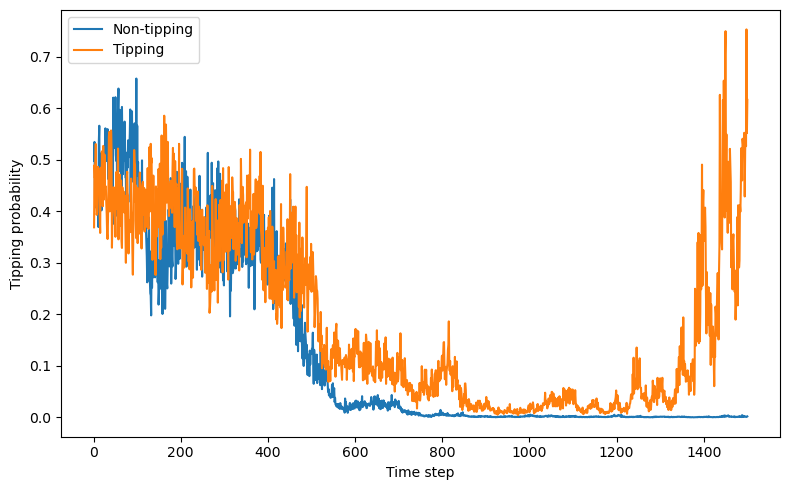

In [9]:
plot_model_on_test(rnn_modelk7, X_test_lowess, y_test_lowess, n_plots=1, plot_mean=False)

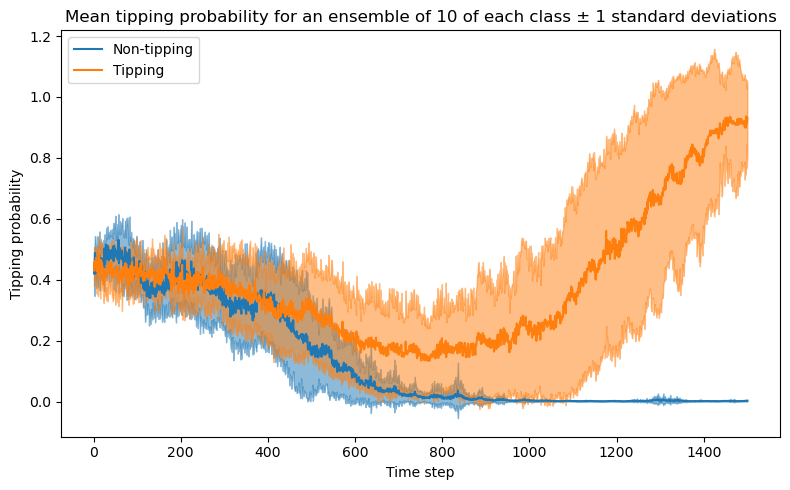

In [10]:
plot_model_on_test(rnn_modelk7, X_test_lowess, y_test_lowess, n_plots=10, plot_mean=True)

In [11]:

rnn_modelk15path = "PreTrainedModels/CNN_LSTM_kernel_size=15_hidden_size=50_features=50_smoothing=lowess_model_weights.pth"
rnn_modelk15 = CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=15, input_size=1, output_size=2
).to(device)

rnn_modelk15.load_state_dict(torch.load(rnn_modelk15path, map_location=device))

<All keys matched successfully>

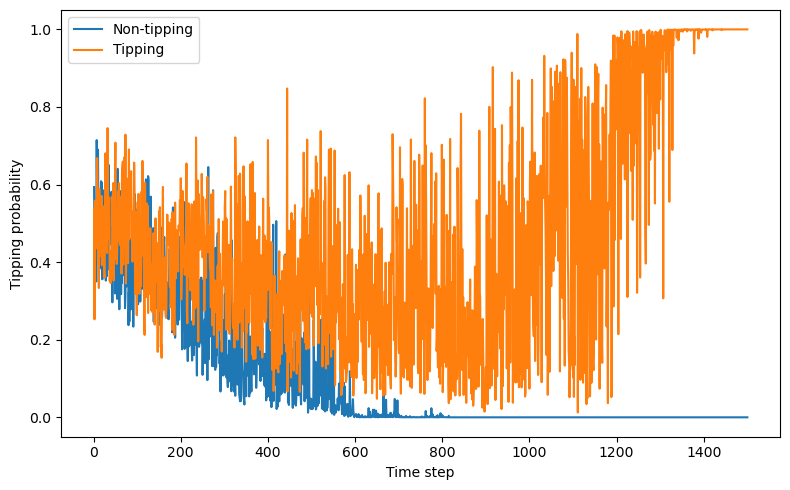

In [14]:
plot_model_on_test(rnn_modelk15, X_test_lowess, y_test_lowess, n_plots=1, plot_mean=False, seed=1)

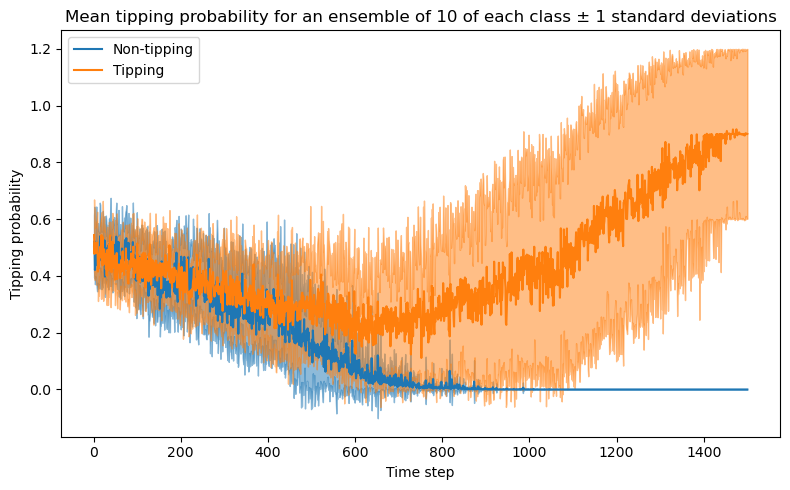

In [15]:

plot_model_on_test(rnn_modelk15, X_test_lowess, y_test_lowess, n_plots=10, plot_mean=True)

In [16]:

rnn_modelk50path = "PreTrainedModels/CNN_LSTM_kernel_size=50_hidden_size=50_features=50_smoothing=lowess_model_weights.pth"
rnn_modelk50 = CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=50, input_size=1, output_size=2
).to(device)


rnn_modelk50.load_state_dict(torch.load(rnn_modelk50path, map_location=device))

<All keys matched successfully>

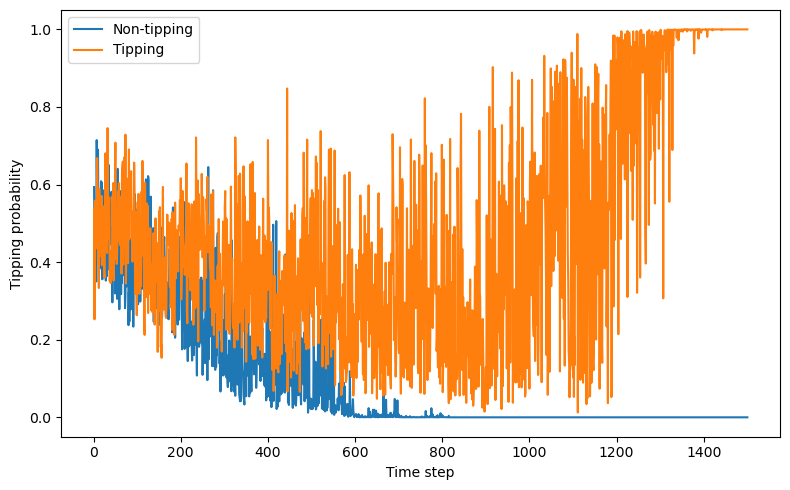

In [18]:

plot_model_on_test(rnn_modelk15, X_test_lowess, y_test_lowess, n_plots=1, plot_mean=False, seed = 1)

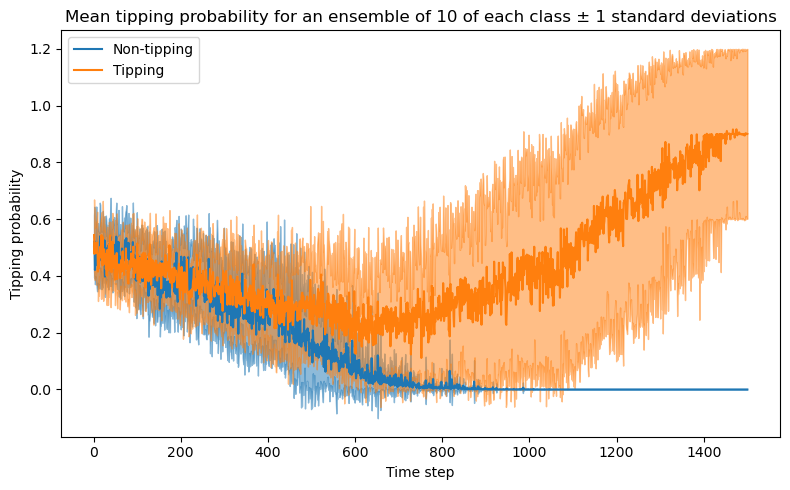

In [19]:

plot_model_on_test(rnn_modelk15, X_test_lowess, y_test_lowess, n_plots=10, plot_mean=True)

It can be seen that with smaller kernel size, your result tend to be smoother while larger kernel sizes tend to give noiser predictions. In fact, if you do not use a CNN and just apply an RNN to the time series, it may just learn the smoothed version of the time series which may not be useful for anticipating tipping. However, large kernel sizes usually require larger training set to reach convergence since the will be more trainable parameters. Thus a trade-off must be made between too large or too small kernel sizes. Notice also that the uncertanty remain large for small kernel sizes at all lead times while large kernel sizes tend to have smaller uncertanity close to tipping.  In application such as image processing where CNNs are used heavily, kernel sizes of more than $7$ are very unusual. Unless their is need, kernel sizes of between $3$ to $15$ should be sufficient for most applications of CNNs. 



**2. The role of detrending**

There is some evidence that the choice of detrending and parameters such as bandwidth can result in vastly different performances for the same DL model (see [Deblander and Bury 2022](https://www.pnas.org/doi/10.1073/pnas.2207720119)). The main choices are detrending by `Gaussian` smoothing (similar to [Nadaraya-Watson Kernel Smoothing](https://en.wikipedia.org/wiki/Kernel_regression)) or smoothing by [locally weighted regression](https://en.wikipedia.org/wiki/Local_regression) (`lowes`). In some scenarios, it may not be necessary to detrend the data e.g when predicting rate-induced tipping ([Huang et al. 2024](https://www.nature.com/articles/s42256-024-00937-0)). Here we will compare the performance of the `CNN_LSTM_TippingClassifier` when now supplied with data detrended via `Gaussian` smoothing. Two models stored in 

1. `PreTrainedModels/CNN_LSTM_kernel_size=5_hidden_size=50_features=50_smoothing=Gaussian_model_weights.pth` and

2. `PreTrainedModels/CNN_LSTM_kernel_size=50_hidden_size=50_features=50_smoothing=Gaussian_model_weights.pth` 

were trained on the Gaussian detrended data. Following the code from the previous exercise, 


-  load the models

-  predict the tipping probability using each model. How do the predictions and their uncertainities compare to those from the models trained with Lowess detrended data?



In [20]:

filenames = [("X_train_null_detrended_gaussian.txt", "X_test_null_detrended_gaussian.txt"), 
             ("X_train_saddlenode_detrended_gaussian.txt", "X_test_saddlenode_detrended_gaussian.txt")]
class_labels = [0, 1]

X_train_gaussian, y_train_gaussian, X_test_gaussian, y_test_gaussian = read_X_y_data(
    class_labels=class_labels,
    train_test_files=filenames,
    detrend=False
)

X_test_gaussian = X_test_gaussian.unsqueeze(dim = 1).to(device)

In [21]:

# load model with kernel size 5
rnn_model_gaussiank5 =  CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=5, input_size=1, output_size=2
).to(device)
rnn_model_gaussiank5.load_state_dict(torch.load(
    "PreTrainedModels/CNN_LSTM_kernel_size=5_hidden_size=50_features=50_smoothing=Gaussian_model_weights.pth",
    map_location=device))




rnn_model_gaussiank50 = CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=50, input_size=1, output_size=2
).to(device)
rnn_model_gaussiank50.load_state_dict(torch.load(
    "PreTrainedModels/CNN_LSTM_kernel_size=50_hidden_size=50_features=50_smoothing=Gaussian_model_weights.pth", 
    map_location=device))

<All keys matched successfully>

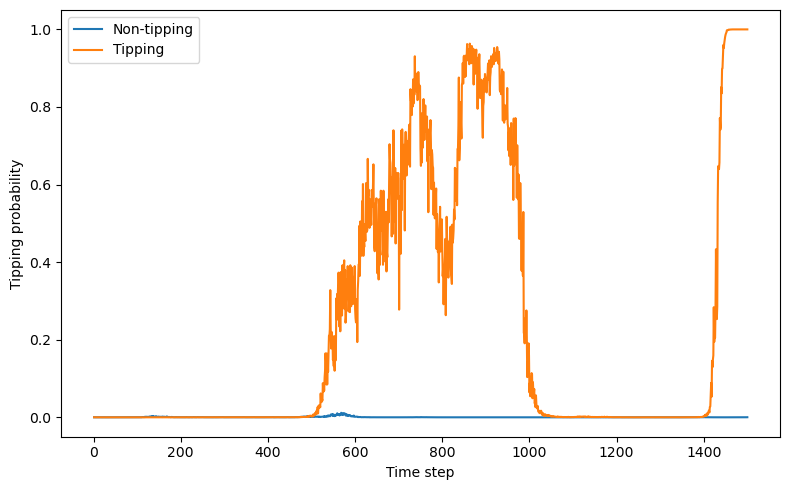

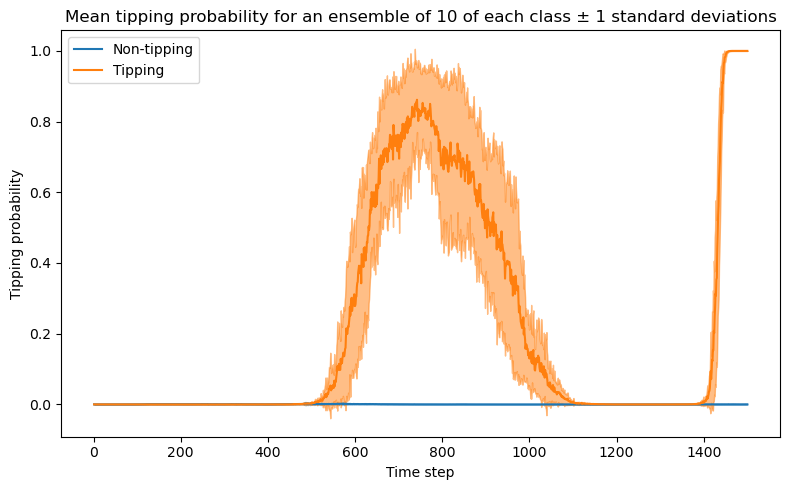

In [22]:
plot_model_on_test(rnn_model_gaussiank5, X_test_gaussian, y_test_gaussian, n_plots=1, plot_mean=False)
plot_model_on_test(rnn_model_gaussiank5, X_test_gaussian, y_test_gaussian, n_plots=10, plot_mean=True)

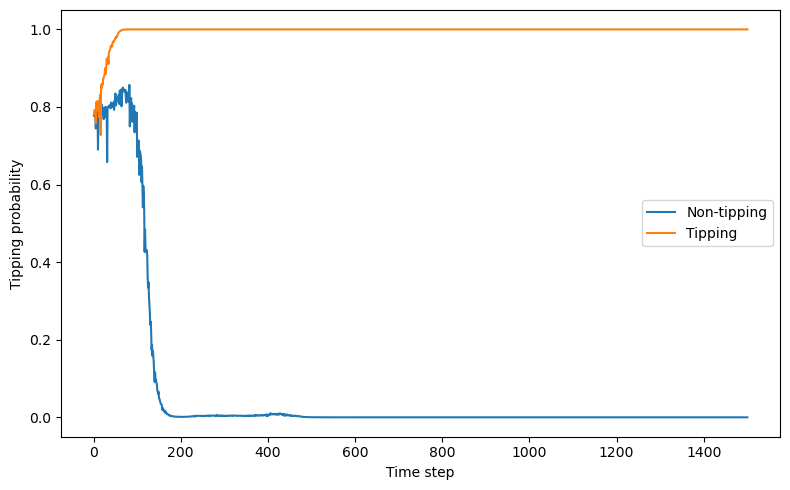

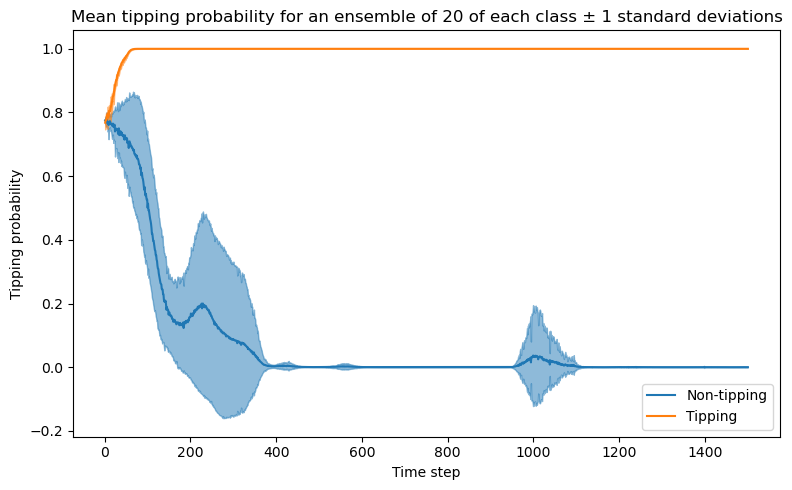

In [23]:

plot_model_on_test(rnn_model_gaussiank50, X_test_gaussian, y_test_gaussian, n_plots=1, plot_mean=False)
plot_model_on_test(rnn_model_gaussiank50, X_test_gaussian, y_test_gaussian, n_plots=20, plot_mean=True)


`Lowess` smoothing is very computational expensive as it fits a separate linear regression model in a given neighbourhood (the size of this neighbourhood is known as the span or bandwidth) but it tend to yield better performing models. On the other hand, `Gaussian` smoothing is extremely fast but DL models trained with this tend to have poor predictive skills. 


**3. Classifying the nature of tipping (may not be possible to do during practical sessions)**

The goal of this exercise is to train your own model to classify between a null model, sadddlenode and transcritical bifurcations, making informed choices on the kernel size and other hyperparameters of the `CNN_LSTM_TippingClassifer` class, and the choice of detrending. The files 

1. `data/X_train_transcritical_detrended_gaussian.txt`, 

2. `data/X_train_transcritical_detrended_lowess.txt`, 

3. `data/X_test_transcritical_detrended_gaussian.txt` and 

4. `data/X_test_transcritical_detrended_lowess.txt` 

contain the corresponding detrended time series for transcritical bifurcation. Use the utility function `prepare_train_test_data` to add shorter sequences and/or control batch size of the training set. Shorter training sequences improve skills at larger lead times away from tipping. The code for training on Lowess detrended data with kernel size of $7$ has been provided.

>- I am hoping we can run some of this training on Google Colab free version but the compute for this plan is limited. Alternatively, you can run the model locally on either GPU or CPU.



#### Training with Lowess detrended data

In [42]:
set_reprodcible_seed()

filenames = [("X_train_null_detrended_lowess.txt", "X_test_null_detrended_lowess.txt"), 
             ("X_train_saddlenode_detrended_lowess.txt", "X_test_saddlenode_detrended_lowess.txt"),
             ("X_train_transcritical_detrended_lowess.txt", "X_test_transcritical_detrended_lowess.txt")]
class_labels = [0, 1, 2]

X_train_lowess_tc, y_train_lowess_tc, X_test_lowess_tc, y_test_lowess_tc = read_X_y_data(
    class_labels=class_labels,
    train_test_files=filenames,
    detrend=False
)


# also you can add shorter sequences to training set. This improve early warning skill on short sequences 
# and larger lead times
X_train_lowess_tc, y_train_lowess_tc, X_test_lowess_tc, y_test_lowess_tc = \
    prepare_train_test_data(X_train_lowess_tc, y_train_lowess_tc, 
                            X_test_lowess_tc, y_test_lowess_tc, 
                            train_num_batches=2,  # increase number of batches if you have memory errors
                            test_num_batches=1,
                            shorter_sequences=True)


rnn_model_lowessk5tc = CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=5, input_size=1, output_size=3 # three classes
).to(device)


loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(rnn_model_lowessk5tc.parameters(), 
                             lr=0.00005, # lr is the learning rate,
                             )

Epoch 20/5000 | Train Loss: 1.900800 | Test Loss: 0.896726
Epoch 40/5000 | Train Loss: 1.876915 | Test Loss: 0.882248
Epoch 60/5000 | Train Loss: 1.856899 | Test Loss: 0.871015
Epoch 80/5000 | Train Loss: 1.843896 | Test Loss: 0.860706
Epoch 100/5000 | Train Loss: 1.822483 | Test Loss: 0.846717
Epoch 120/5000 | Train Loss: 1.804465 | Test Loss: 0.836387
Epoch 140/5000 | Train Loss: 1.790972 | Test Loss: 0.829663
Epoch 160/5000 | Train Loss: 1.770595 | Test Loss: 0.816655
Epoch 180/5000 | Train Loss: 1.753681 | Test Loss: 0.801426
Epoch 200/5000 | Train Loss: 1.757088 | Test Loss: 0.798970
Epoch 220/5000 | Train Loss: 1.727985 | Test Loss: 0.783582
Epoch 240/5000 | Train Loss: 1.889565 | Test Loss: 0.881177
Epoch 260/5000 | Train Loss: 1.724143 | Test Loss: 0.777315
Epoch 280/5000 | Train Loss: 1.706174 | Test Loss: 0.770728
Epoch 300/5000 | Train Loss: 1.695463 | Test Loss: 0.756461
Epoch 320/5000 | Train Loss: 1.677170 | Test Loss: 0.744774
Epoch 340/5000 | Train Loss: 1.684409 | Test

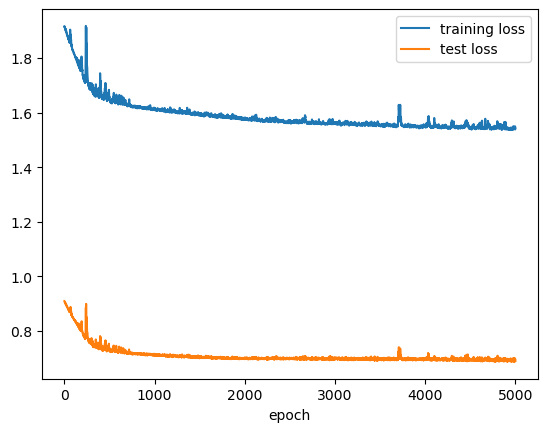

In [71]:

n_epochs = 5000 # may want to reduce this 
print_every = 20
train_losses = []
test_losses = []

train_losses, test_losses = train(rnn_model_lowessk5tc, 
                                  X_train_lowess_tc, y_train_lowess_tc, 
                                  X_test_lowess_tc, y_test_lowess_tc, 
                                  loss_fn, optimizer, train_losses, 
                                  test_losses, n_epochs, print_every)


plot_train_and_test_loss(train_losses, test_losses)

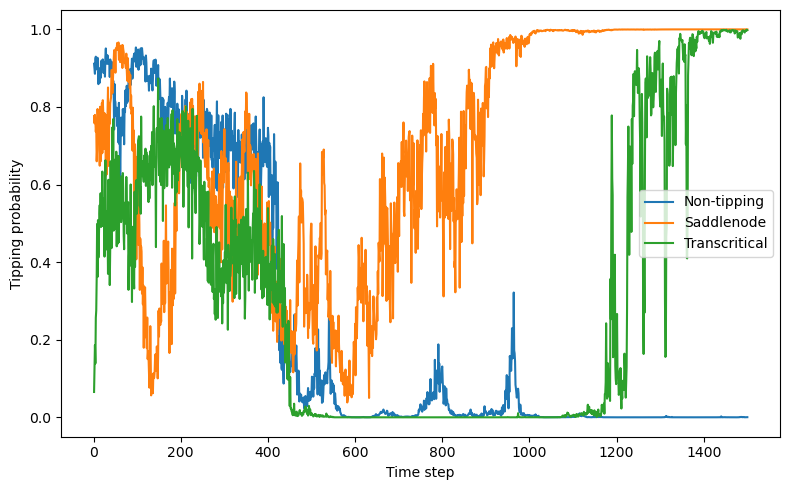

In [72]:

labels=["Non-tipping", "Saddlenode", "Transcritical"]
plot_model_on_test(rnn_model_lowessk5tc, torch.cat(X_test_lowess_tc), torch.cat(y_test_lowess_tc), n_plots=1, plot_mean=False,
                   labels=labels, seed=1)
                   

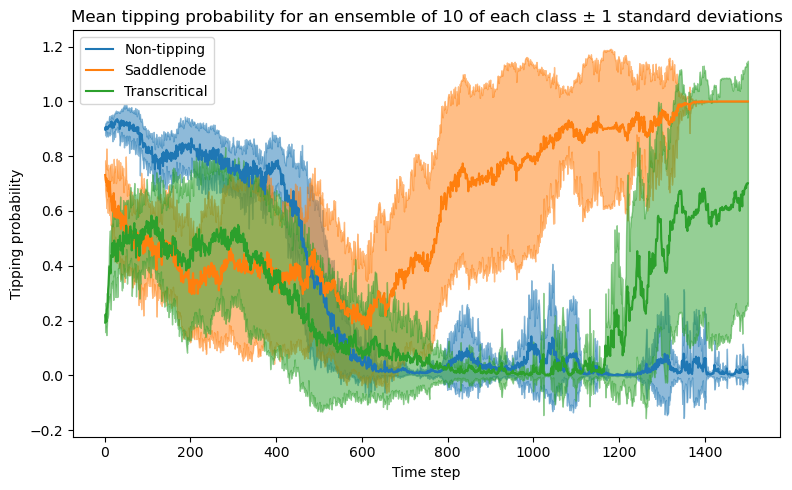

In [73]:
plot_model_on_test(rnn_model_lowessk5tc, torch.cat(X_test_lowess_tc), torch.cat(y_test_lowess_tc), n_plots=10, plot_mean=True,
                   labels=labels)

In [74]:
save_path = os.path.join("PreTrainedModels", "CNN_LSTM_SN_TC_kernel_size=5_hidden_size=50_features=50_detrend=lowess_model_weights.pth")

torch.save(rnn_model_lowessk5tc.state_dict(), save_path)

print(f"Model saved to {save_path}")

Model saved to PreTrainedModels/CNN_LSTM_SN_TC_kernel_size=5_hidden_size=50_features=50_detrend=lowess_model_weights.pth


#### Training the Model with Gaussian detrended data

In [75]:

set_reprodcible_seed()

filenames = [("X_train_null_detrended_gaussian.txt", "X_test_null_detrended_gaussian.txt"), 
             ("X_train_saddlenode_detrended_gaussian.txt", "X_test_saddlenode_detrended_gaussian.txt"),
             ("X_train_transcritical_detrended_gaussian.txt", "X_test_transcritical_detrended_gaussian.txt")]
class_labels = [0, 1, 2]

X_train_gaussian_tc, y_train_gaussian_tc, X_test_gaussian_tc, y_test_gaussian_tc = read_X_y_data(
    class_labels=class_labels,
    train_test_files=filenames,
    detrend=False
)


# also you can add shorter sequences to training set. This improve early warning skill on short sequences 
# and larger lead times
X_train_gaussian_tc, y_train_gaussian_tc, X_test_gaussian_tc, y_test_gaussian_tc = \
    prepare_train_test_data(X_train_gaussian_tc, y_train_gaussian_tc, 
                            X_test_gaussian_tc, y_test_gaussian_tc, 
                            train_num_batches=2,  # increase number of batches if you have memory errors
                            test_num_batches=1,
                            shorter_sequences=True)


rnn_model_gaussiank5tc = CNN_LSTM_TippingClassifier(
    hidden_size=50, n_features=50, kernel_size=5, input_size=1, output_size=3 # three classes
).to(device)


loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(rnn_model_gaussiank5tc.parameters(), 
                             lr=0.00005, # lr is the learning rate,
                             )

Epoch 20/5000 | Train Loss: 2.195172 | Test Loss: 1.096543
Epoch 40/5000 | Train Loss: 2.188295 | Test Loss: 1.089605
Epoch 60/5000 | Train Loss: 2.165073 | Test Loss: 1.066659
Epoch 80/5000 | Train Loss: 2.097962 | Test Loss: 1.003149
Epoch 100/5000 | Train Loss: 2.014588 | Test Loss: 0.931276
Epoch 120/5000 | Train Loss: 1.948890 | Test Loss: 0.887223
Epoch 140/5000 | Train Loss: 1.902137 | Test Loss: 0.860478
Epoch 160/5000 | Train Loss: 1.875175 | Test Loss: 0.848311
Epoch 180/5000 | Train Loss: 1.861349 | Test Loss: 0.843151
Epoch 200/5000 | Train Loss: 1.854869 | Test Loss: 0.840763
Epoch 220/5000 | Train Loss: 1.851740 | Test Loss: 0.837844
Epoch 240/5000 | Train Loss: 1.849877 | Test Loss: 0.835643
Epoch 260/5000 | Train Loss: 1.849059 | Test Loss: 0.833749
Epoch 280/5000 | Train Loss: 1.848210 | Test Loss: 0.832586
Epoch 300/5000 | Train Loss: 1.848060 | Test Loss: 0.831503
Epoch 320/5000 | Train Loss: 1.847784 | Test Loss: 0.830831
Epoch 340/5000 | Train Loss: 1.847385 | Test

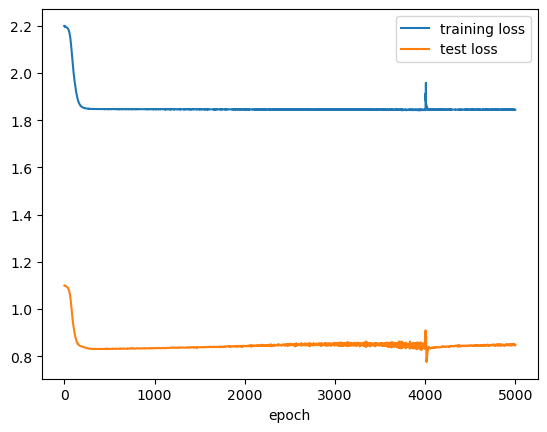

In [76]:

n_epochs = 5000 
print_every = 20
train_losses = []
test_losses = []

train_losses, test_losses = train(rnn_model_gaussiank5tc, 
                                  X_train_gaussian_tc, y_train_gaussian_tc, 
                                  X_test_gaussian_tc, y_test_gaussian_tc, 
                                  loss_fn, optimizer, train_losses, 
                                  test_losses, n_epochs, print_every)


plot_train_and_test_loss(train_losses, test_losses)

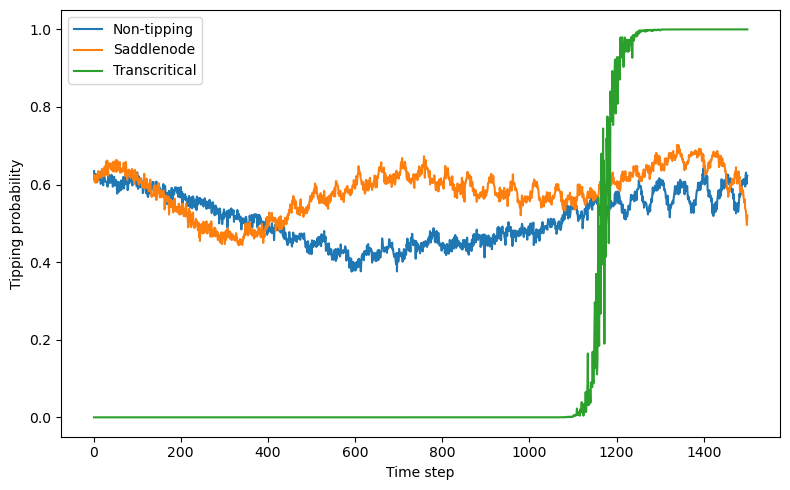

In [77]:

labels=["Non-tipping", "Saddlenode", "Transcritical"]
plot_model_on_test(rnn_model_gaussiank5tc, torch.cat(X_test_gaussian_tc), torch.cat(y_test_gaussian_tc), n_plots=1, plot_mean=False,
                   labels=labels, seed=1)
                   

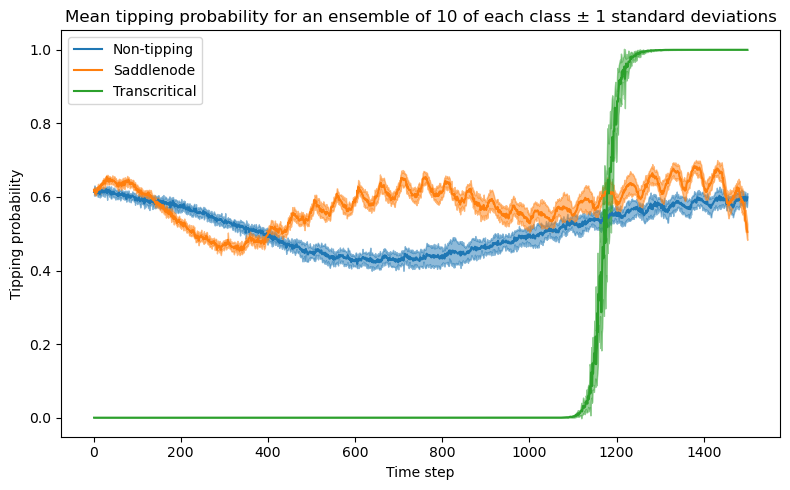

In [79]:

plot_model_on_test(rnn_model_gaussiank5tc, torch.cat(X_test_gaussian_tc), torch.cat(y_test_gaussian_tc), n_plots=10, plot_mean=True,
                   labels=labels)

In [78]:

save_path = os.path.join("PreTrainedModels", "CNN_LSTM_SN_TC_kernel_size=5_hidden_size=50_features=50_detrend=gaussian_model_weights.pth")

torch.save(rnn_model_gaussiank5tc.state_dict(), save_path)

print(f"Model saved to {save_path}")

Model saved to PreTrainedModels/CNN_LSTM_SN_TC_kernel_size=5_hidden_size=50_features=50_detrend=gaussian_model_weights.pth
